# Exp3 Sequential Recommendation Result Check

Rendered result check with CSV previews and embedded PNG figures. This notebook reads existing outputs only.

In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

rows = []
for name in ['README.md','requirements.txt','reproduce_fast.py','reproduce_full.py','reproduce_paper.py','code_check.py','self_check.py','output_manifest.md','docs','outputs','runlogs']:
    rows.append({'path': name, 'exists': (ROOT/name).exists()})
display(pd.DataFrame(rows))
missing = [row['path'] for row in rows if not row['exists'] and row['path'] in {'README.md','outputs'}]
if missing:
    display(Markdown('Warning: required display/interface paths missing: ' + ', '.join(missing)))
else:
    display(Markdown('Required GitHub display paths are present.'))


,path,exists
0,README.md,True
1,requirements.txt,True
2,reproduce_fast.py,True
3,reproduce_full.py,True
4,reproduce_paper.py,False
5,code_check.py,True
6,self_check.py,True
7,output_manifest.md,False
8,docs,True
9,outputs,True


Required GitHub display paths are present.

In [2]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

csvs = prefer_outputs(find_files(['outputs/**/summaries/*.csv','outputs/**/summary/*.csv','outputs/**/tables/*.csv','outputs/**/checks/*.csv','outputs/**/metadata/*.csv']))
display(Markdown(f'Found `{len(csvs)}` CSV/table/check/metadata files. Showing selected previews.'))
for path in csvs[:6]:
    show_dataframe(path)


Found `41` CSV/table/check/metadata files. Showing selected previews.

**outputs/full/checks/code_check_report.csv**

,check_id,status,n_errors,details
0,code_check,passed,0,CODE CHECK PASSED


Rows: `1` | Columns: `4`

**outputs/full/checks/input_schema_report.csv**

...

,input_path,file_name,required_for_primary,size_bytes,sha256
0,/home/ubuntu/crmd_df/runs/exp3_cloud_20260622_...,log_standard_4_22_to_5_08_1k.csv,True,492303531,548daf771e54e2b73086cc8e7c6f56787d44421f5026c2...
1,/home/ubuntu/crmd_df/runs/exp3_cloud_20260622_...,log_standard_4_08_to_4_21_1k.csv,True,373670312,355355897a84baa4df26b78b0271bb9a27b127a39cd7aa...
2,/home/ubuntu/crmd_df/runs/exp3_cloud_20260622_...,video_features_basic_1k.csv,True,376887905,18cb8b9133635a5e53d4e33b1644137b8673b615cc1aaa...
3,/home/ubuntu/crmd_df/runs/exp3_cloud_20260622_...,log_random_4_22_to_5_08_1k.csv,False,3086015,e98841eabb3b078c812c4646bf0c5e3f0c947a4183dd95...


Rows: `4` | Columns: `5`

**outputs/full/metadata/method_information_contract.csv**

,method_id,method_display_name,information_interface,reference_role,diagnostic_only,deployable
0,arrival_time_naive,Arrival-time carrier,arrival_time_carrier,none,False,False
1,source_labelled_empirical,Source-labelled empirical,source_labelled,source_labelled_control,True,False
2,source_aware_reference,Source-aware reference,offline_source_target,source_aware_reference,False,False
3,partial_source_label_q10,"Partial source labels, q=0.10",partial_source_label,none,False,False
4,partial_source_label_q30,"Partial source labels, q=0.30",partial_source_label,none,False,False
5,partial_source_label_q50,"Partial source labels, q=0.50",partial_source_label,none,False,False
6,history_mean_static,History mean static,history_target_mean_only,diagnostic_control,True,False
7,short_term_ridge_proxy,Short-term ridge proxy,lagged_short_term_proxy,none,False,False


Rows: `10` | Columns: `6`

Found `4` PNG figure files. Showing selected embedded figures.

**outputs/full/figures/png/fig_app_exp3_horizon_eligibility.png**

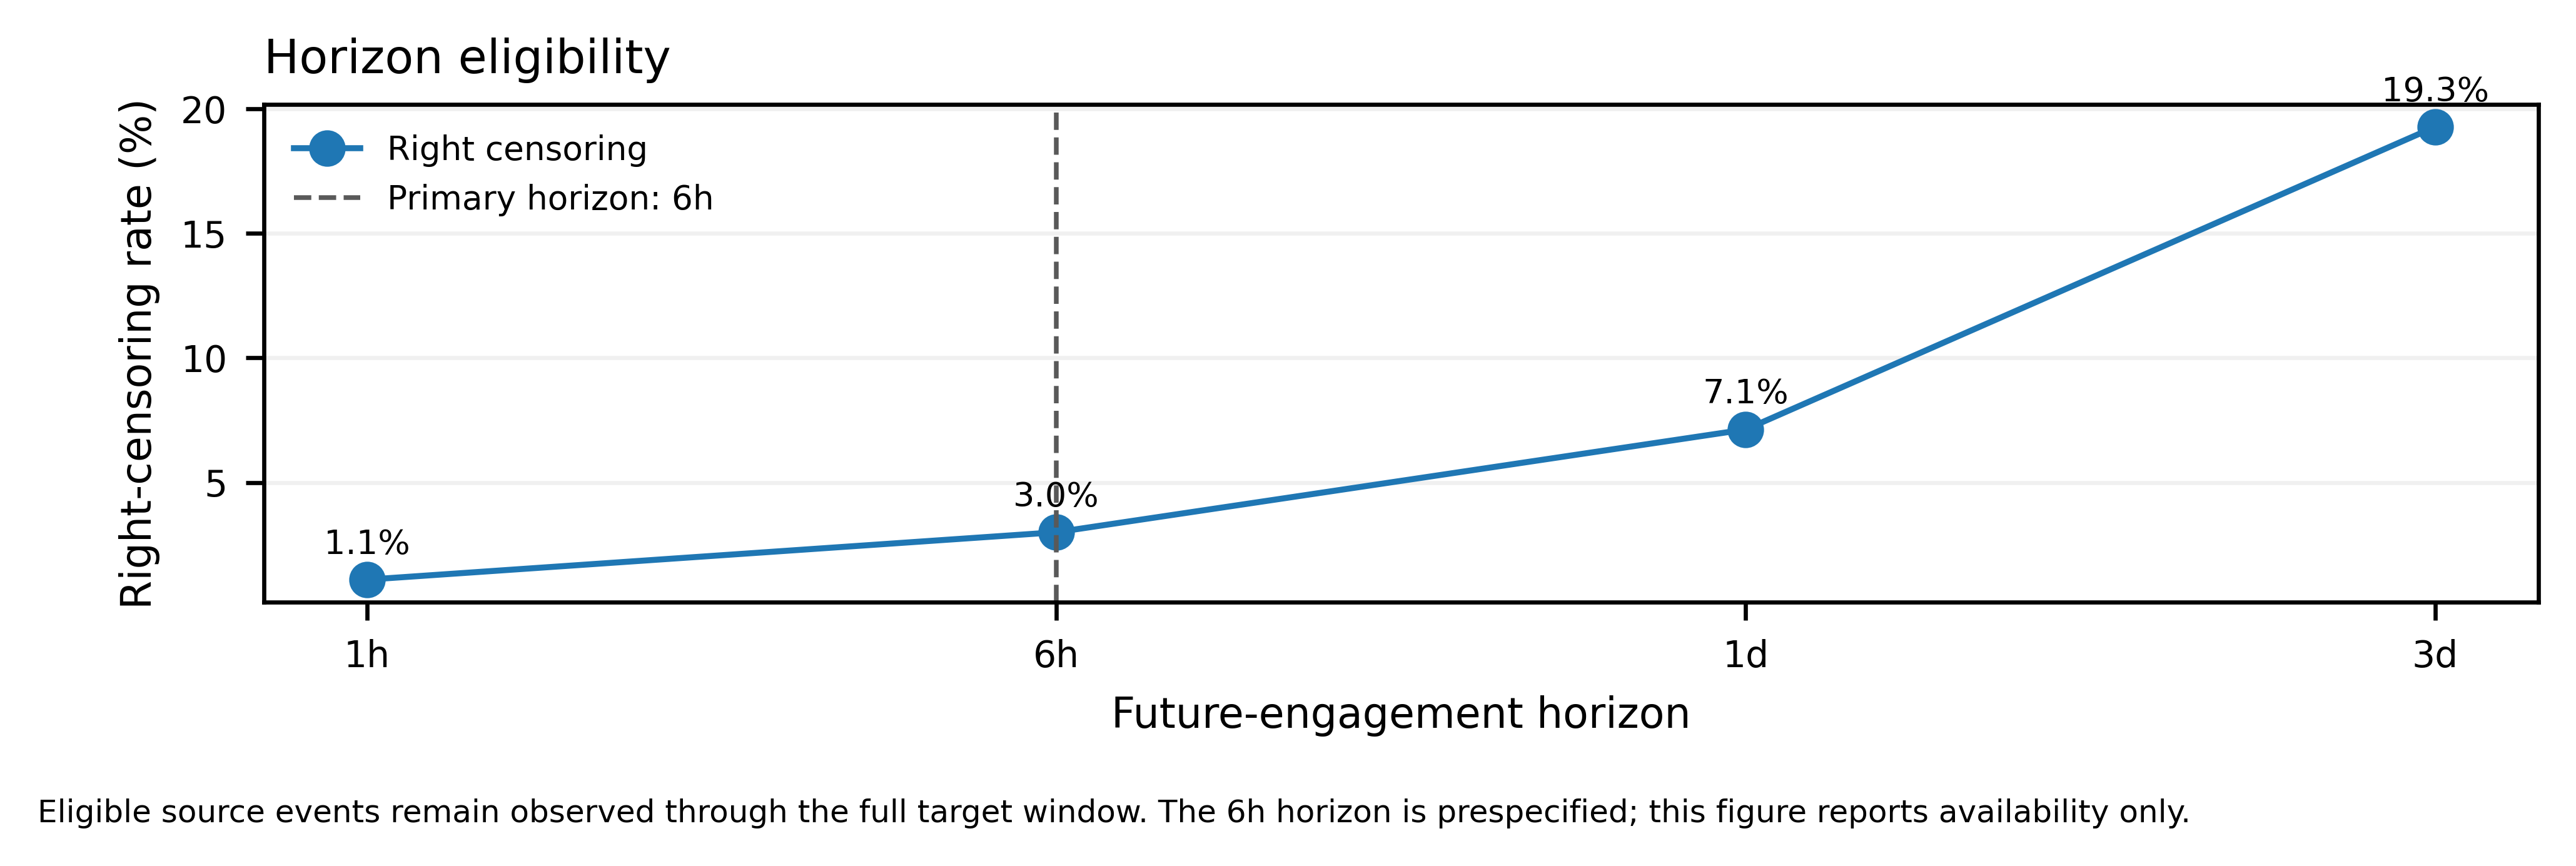

**outputs/full/figures/png/fig_exp3_long_term_recoverability.png**

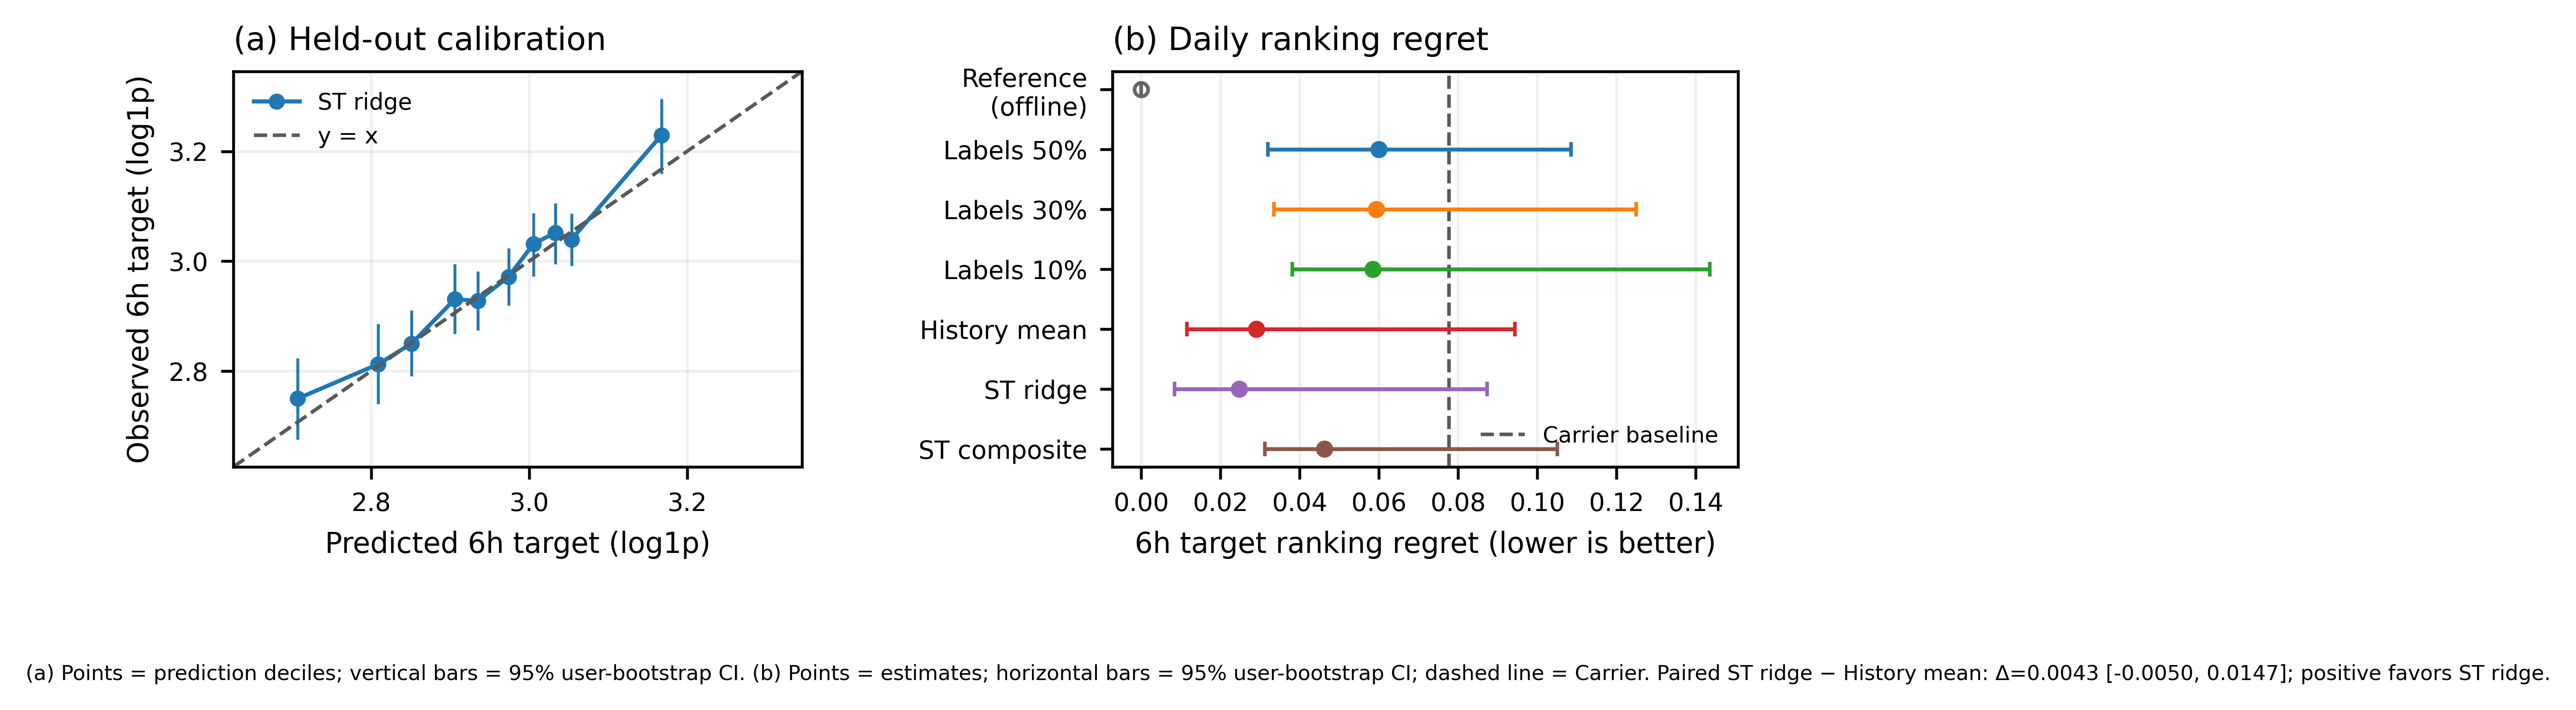

**outputs/fast/figures/png/fig_app_exp3_horizon_eligibility.png**

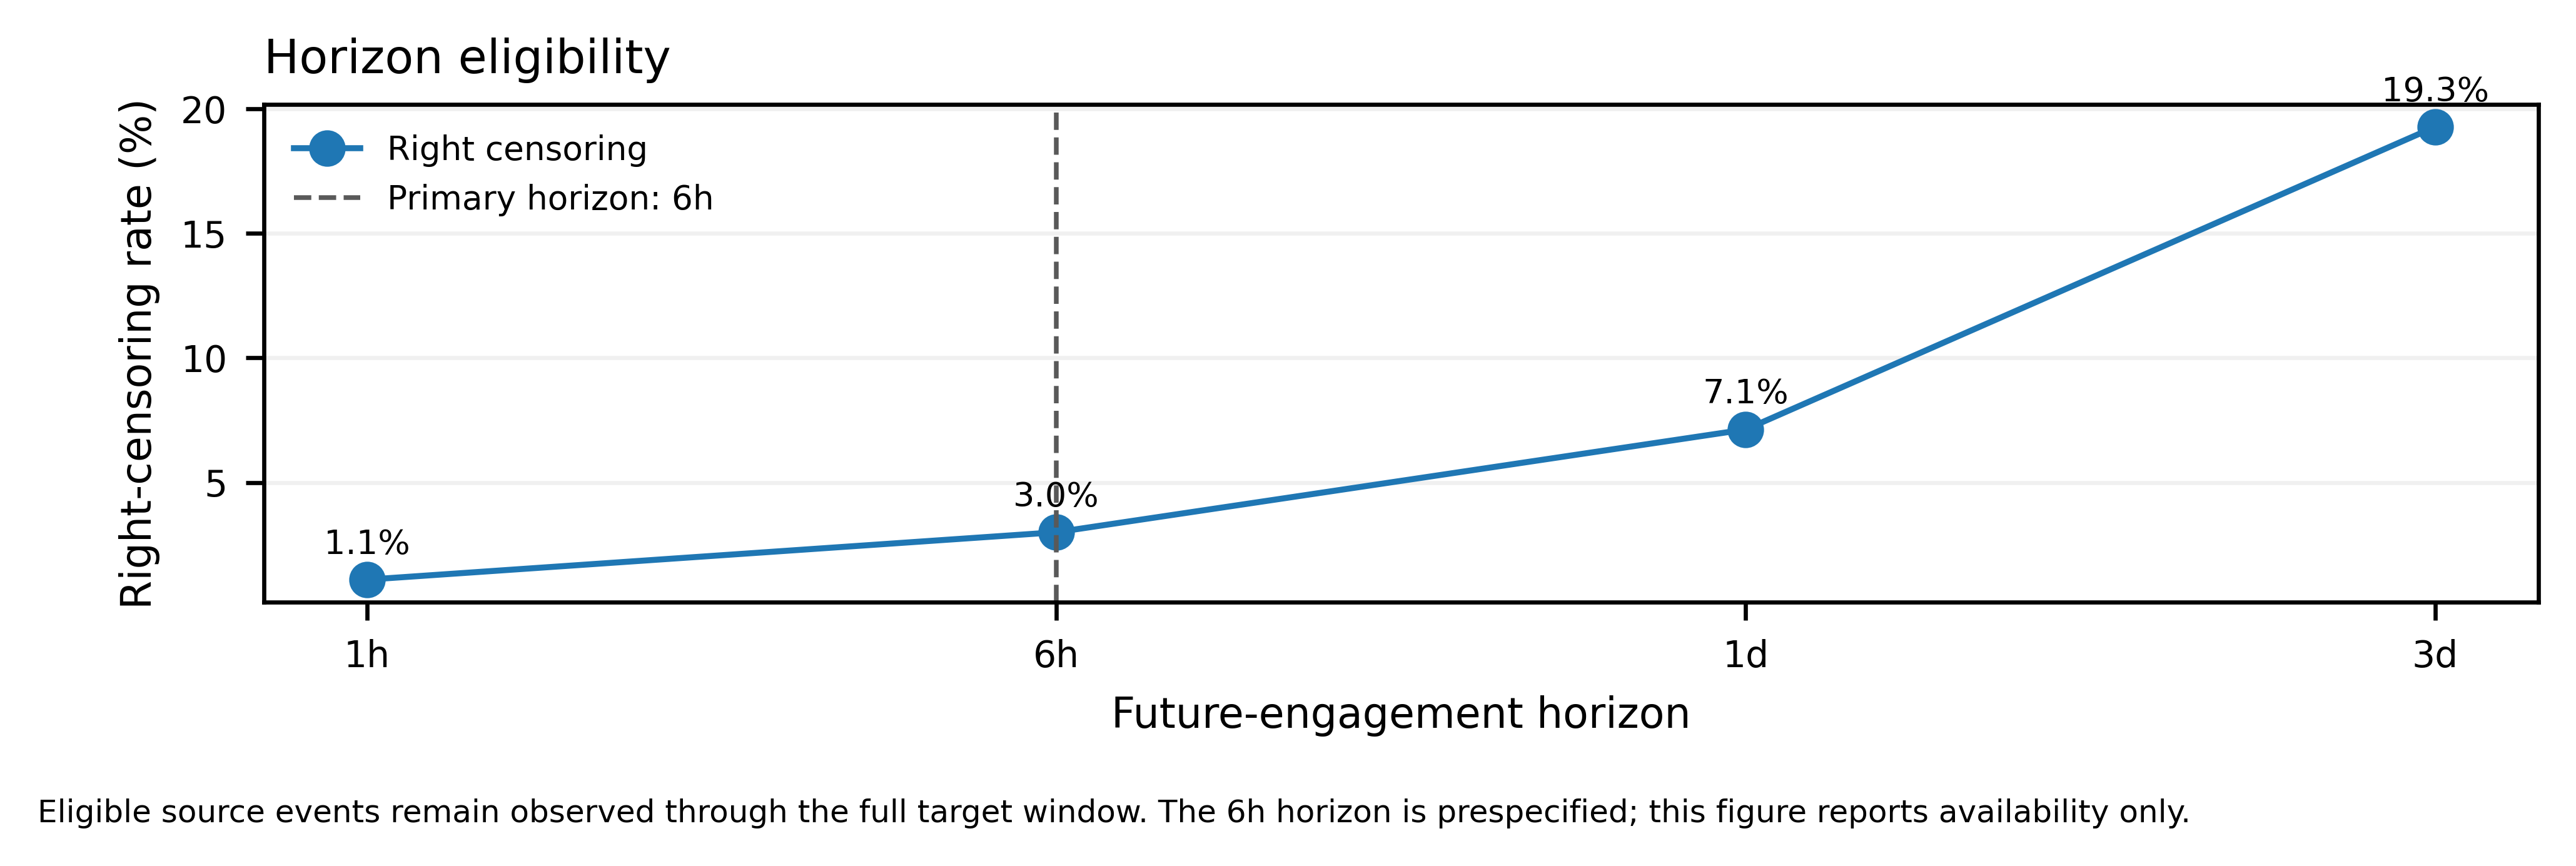

**outputs/fast/figures/png/fig_exp3_long_term_recoverability.png**

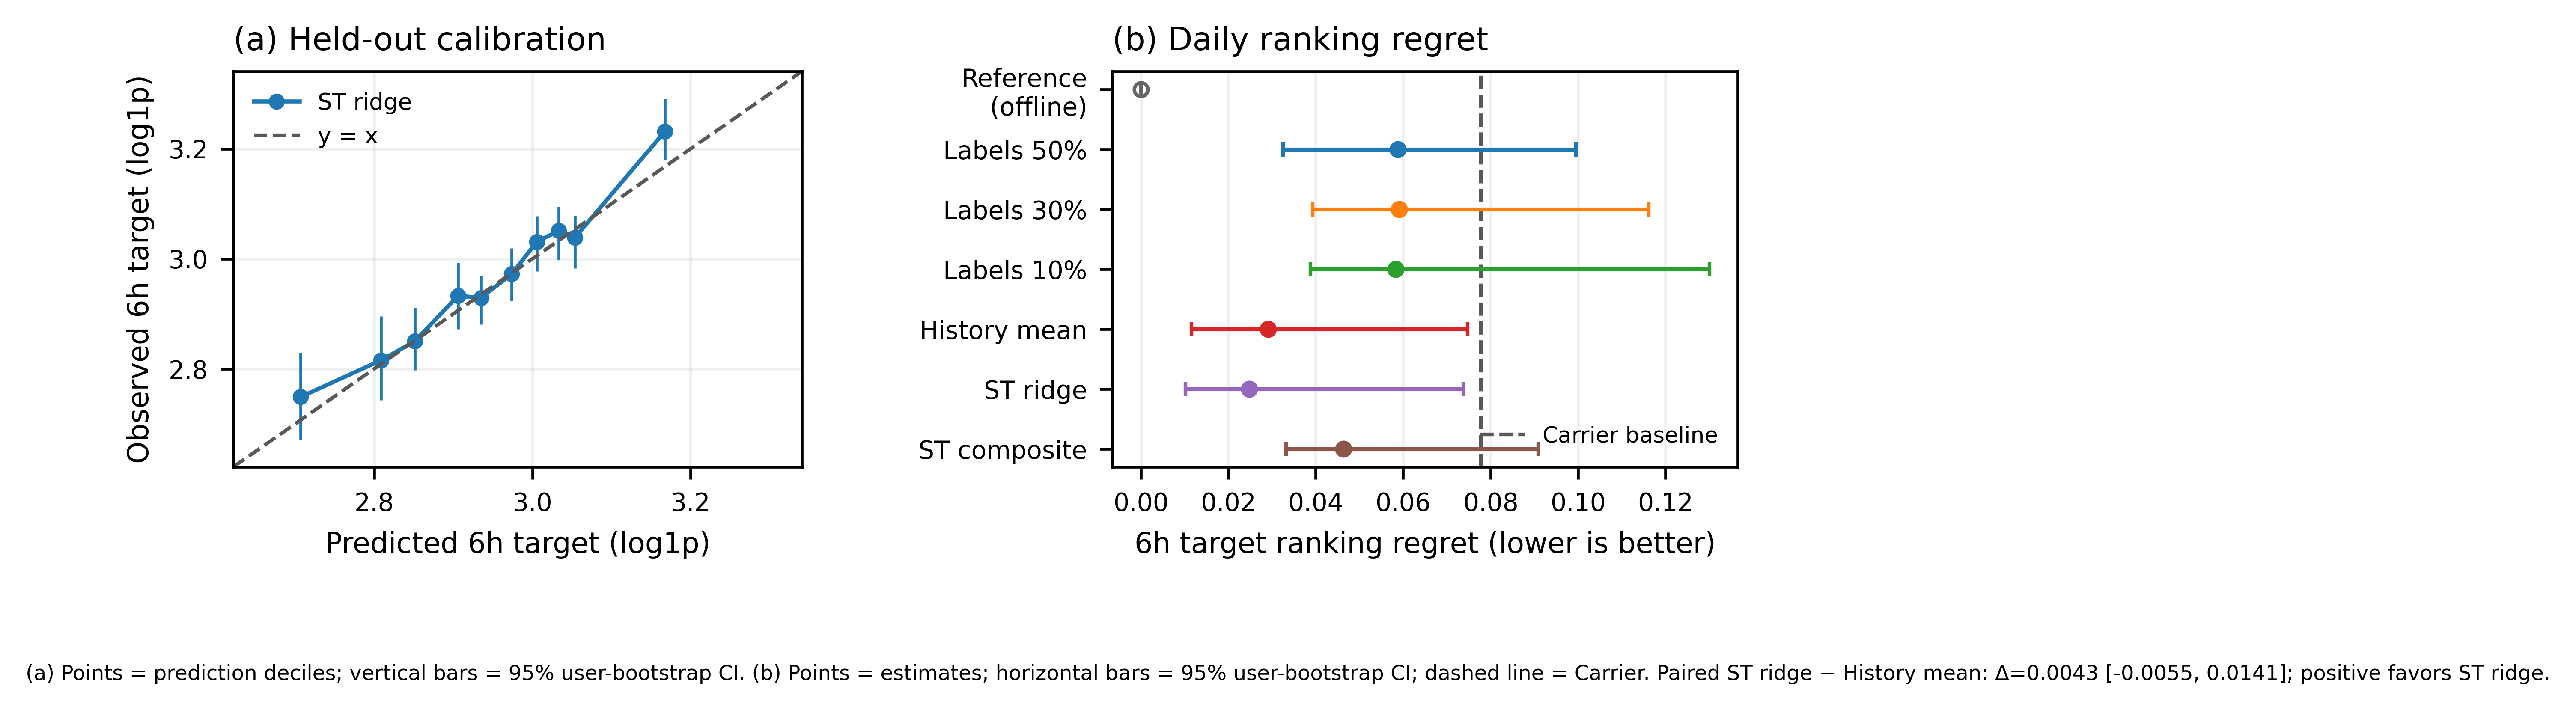

In [3]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

figures = prefer_outputs(find_files(['outputs/**/figures/**/*.png']))
display(Markdown(f'Found `{len(figures)}` PNG figure files. Showing selected embedded figures.'))
show_images(figures, limit=4)


In [4]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

logs = find_files(['runlogs/*','outputs/**/logs/*','*.log','outputs/**/checks/*'])
log_rows = [{'path': rel(p), 'size_kb': round(p.stat().st_size/1024, 1)} for p in logs[:30]]
display(Markdown(f'Found `{len(logs)}` runlog/check records.'))
display(pd.DataFrame(log_rows))
if not csvs:
    display(Markdown('Warning: no summary/table CSV detected under outputs/.'))
if not figures:
    display(Markdown('Warning: no figure PNG detected under outputs/.'))
display(Markdown('This notebook only reads existing outputs; no experiment entrypoint was executed.'))


Found `11` runlog/check records.

,path,size_kb
0,code_check.log,0.3
1,fast.log,0.1
2,full_self_check.log,0.1
3,outputs/fast/checks/code_check_report.csv,0.1
4,outputs/fast/checks/input_schema_report.csv,3.4
5,outputs/fast/checks/self_check_report.csv,0.1
6,outputs/full/checks/code_check_report.csv,0.1
7,outputs/full/checks/input_schema_report.csv,3.3
8,outputs/full/checks/self_check_report.csv,0.1
9,runlogs/full_run.log,0.2


This notebook only reads existing outputs; no experiment entrypoint was executed.